In [ ]:
import os
import pickle

import pandas as pd
import torch
from loadforecasting_models import Gam
from pygam import f, s, te

from home_bess.interfaces import get_weather_data

In [2]:
"""Read in the historic load profile"""

df_load = pd.read_csv("../interfaces/energy_data.csv", index_col=0)
df_load.index = pd.to_datetime(df_load.index, utc=True)
df_load.index = df_load.index.tz_convert("Europe/Vienna")
net_load_profile = df_load["Consumption"] - df_load["Production"]
net_load_profile = net_load_profile / 1000.0  # Umrechnung in kW
net_load_profile = net_load_profile["2025-01-01":"2025-12-31"]
net_load_profile

date
2025-01-01 00:00:00+01:00    0.126960
2025-01-01 00:15:00+01:00    0.155287
2025-01-01 00:30:00+01:00    0.128953
2025-01-01 00:45:00+01:00    0.127864
2025-01-01 01:00:00+01:00    0.155904
                               ...   
2025-12-31 22:45:00+01:00    2.018537
2025-12-31 23:00:00+01:00    1.479814
2025-12-31 23:15:00+01:00    0.098641
2025-12-31 23:30:00+01:00    0.105715
2025-12-31 23:45:00+01:00    1.353831
Length: 35040, dtype: float64

In [ ]:
"""Read in the historic weather data"""

weather_data = get_weather_data.WeatherDataRetriever().retrieve_weather_data(
    start_date="2025-01-01",
    end_date="2025-12-31",
    weather_actuality="actual",
)
weather_data

,temperature_2m,relative_humidity_2m,shortwave_radiation,diffuse_radiation,direct_normal_irradiance,global_tilted_irradiance,direct_radiation,cloud_cover,wind_speed_10m,wind_direction_10m,precipitation
date,,,,,,,,,,,
2025-01-01 00:00:00+01:00,-1.7795,89.0,0.0,0.0,0.0,0.0,0.0,0.0,3.259938,173.659897,0.0
2025-01-01 00:15:00+01:00,-1.8795,89.0,0.0,0.0,0.0,0.0,0.0,0.0,3.415260,161.564957,0.0
2025-01-01 00:30:00+01:00,-1.9795,89.0,0.0,0.0,0.0,0.0,0.0,0.0,3.600000,143.130020,0.0
2025-01-01 00:45:00+01:00,-2.0795,88.0,0.0,0.0,0.0,0.0,0.0,0.0,4.334974,131.633453,0.0
2025-01-01 01:00:00+01:00,-2.1795,88.0,0.0,0.0,0.0,0.0,0.0,0.0,4.693826,122.471176,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 22:45:00+01:00,-7.8295,76.0,0.0,0.0,0.0,0.0,0.0,0.0,3.617955,185.710495,0.0
2025-12-31 23:00:00+01:00,-7.8295,76.0,0.0,0.0,0.0,0.0,0.0,0.0,3.617955,185.710495,0.0
2025-12-31 23:15:00+01:00,-7.8795,76.0,0.0,0.0,0.0,0.0,0.0,0.0,3.617955,185.710495,0.0


In [ ]:
"""Create features for the forecasting model"""

lag = 7 * 24 * 4  # 7 Tage * 24 Stunden * 4 (15-Minuten-Intervalle)

features_df = pd.DataFrame(
    {
        "hour_of_day": weather_data.index.hour,
        "day_of_week": weather_data.index.dayofweek,
        "temperature_2m": weather_data["temperature_2m"],
        "wind_speed_10m": weather_data["wind_speed_10m"],
        "global_tilted_irradiance": weather_data["global_tilted_irradiance"],
        "lag_7_days": net_load_profile.shift(lag),
    }
)

# Cut the first 7 days, because of the 7d lag
net_load_profile = net_load_profile[lag:]
features_df = features_df[lag:]

features_df

,hour_of_day,day_of_week,temperature_2m,wind_speed_10m,global_tilted_irradiance,lag_7_days
date,,,,,,
2025-01-08 00:00:00+01:00,0,2,-1.7295,5.634891,0.0,0.126960
2025-01-08 00:15:00+01:00,0,2,-1.8295,6.287130,0.0,0.155287
2025-01-08 00:30:00+01:00,0,2,-1.9295,7.517021,0.0,0.128953
2025-01-08 00:45:00+01:00,0,2,-1.9795,8.825508,0.0,0.127864
2025-01-08 01:00:00+01:00,1,2,-1.9795,9.826088,0.0,0.155904
...,...,...,...,...,...,...
2025-12-31 22:45:00+01:00,22,2,-7.8295,3.617955,0.0,0.086552
2025-12-31 23:00:00+01:00,23,2,-7.8295,3.617955,0.0,0.111567
2025-12-31 23:15:00+01:00,23,2,-7.8795,3.617955,0.0,1.816466


In [ ]:
"""Create and train the forecasting model"""

features_names = features_df.columns.tolist()

all_gam_terms = (
    s(features_names.index("lag_7_days"))
    + f(features_names.index("day_of_week"))
    + te(
        s(features_names.index("hour_of_day"), n_splines=5),
        s(features_names.index("temperature_2m"), n_splines=5),
    )
    + te(
        s(features_names.index("hour_of_day"), n_splines=10, lam=0.3),
        s(features_names.index("global_tilted_irradiance"), n_splines=10, lam=0.15),
    )
    + te(
        s(features_names.index("temperature_2m"), n_splines=10, lam=0.3),
        s(features_names.index("wind_speed_10m"), n_splines=10, lam=0.15),
    )
)

my_model = Gam(all_gam_terms)
x = features_df.values
y = net_load_profile.values
history = my_model.train_model(x, y)
predictions = my_model.predict(x)


def calculate_nmae(y_true: pd.Series | torch.Tensor, y_pred: pd.Series | torch.Tensor) -> float:
    loss_fn = torch.nn.L1Loss()
    reference = y_true.max() - y_true.min()
    mae = loss_fn(torch.tensor(y_pred, dtype=torch.float32), torch.tensor(y_true, dtype=torch.float32))
    n_mae = 100.0 * mae / reference
    return n_mae.item()


nmae = calculate_nmae(net_load_profile.values, predictions)
print(f"nMae: {nmae:.2f}%")

NMAE: 3.45%


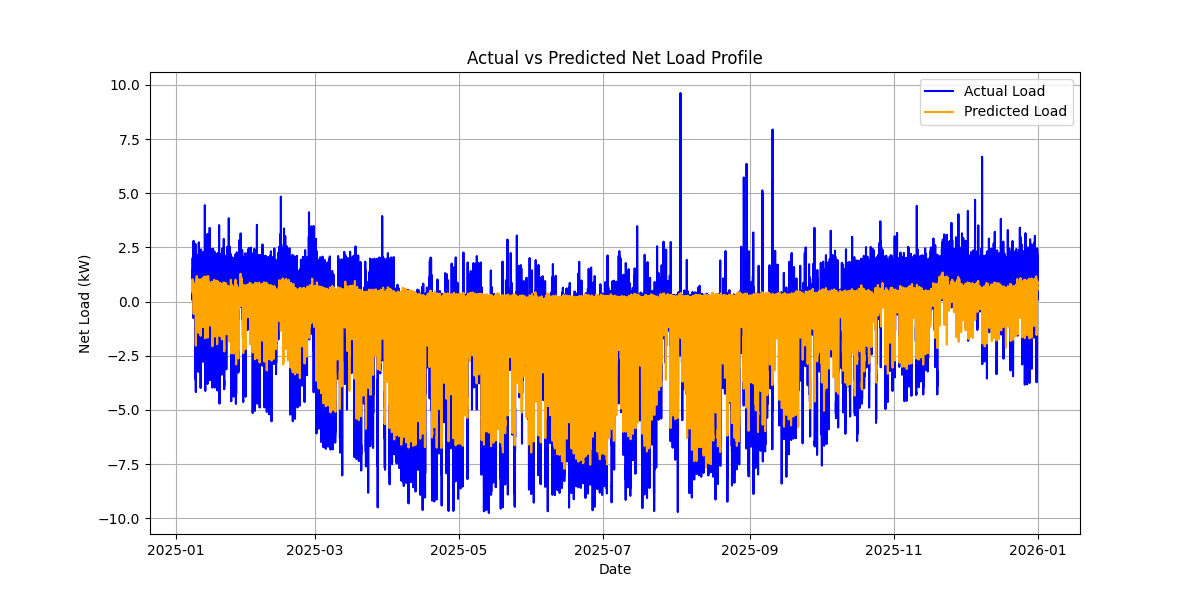

In [ ]:
import matplotlib.pyplot as plt

%matplotlib widget

# Plot actual vs predicted load profile
plt.figure(figsize=(12, 6))
plt.plot(net_load_profile.index, net_load_profile.values, label="Actual Load", color="blue")
plt.plot(net_load_profile.index, predictions, label="Predicted Load", color="orange")
plt.xlabel("Date")
plt.ylabel("Net Load (kW)")
plt.title("Actual vs Predicted Net Load Profile")
plt.legend()
plt.grid()
plt.show()

In [ ]:
"""Create and save the model as a pickle file. """

filename = "gam_model.pkl"

if os.path.exists(filename):
    print(f"File {filename} already exists.")
else:
    with open(filename, "wb") as f:
        pickle.dump(my_model, f)

File gam_model.pkl already exists. Please choose a different name or check the existing file.
